Starting LSTM Time-Series Cross-Validation...


C:\Users\W11\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 1 completed: R²=0.8367, NMSE=0.0113, NMAE=0.0648


C:\Users\W11\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 2 completed: R²=0.5474, NMSE=0.0194, NMAE=0.0464


...

Fold 3 completed: R²=0.7940, NMSE=0.0115, NMAE=0.0622


C:\Users\W11\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 4 completed: R²=0.9209, NMSE=0.0054, NMAE=0.0348


C:\Users\W11\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 5 completed: R²=0.9401, NMSE=0.0033, NMAE=0.0317

========= LSTM TIME-SERIES CV RESULTS =========
NMAE : 0.0480 ± 0.0136
NMSE : 0.0102 ± 0.0056
R²   : 0.8078 ± 0.1408
MAPE : 29.31% ± 7.24%

========== DIEBOLD-MARIANO TEST RESULT ==========
Comparison : LSTM Prediction vs. Naive Baseline (Lag 12)
DM Stat    : -5.2414
p-value    : 0.0000


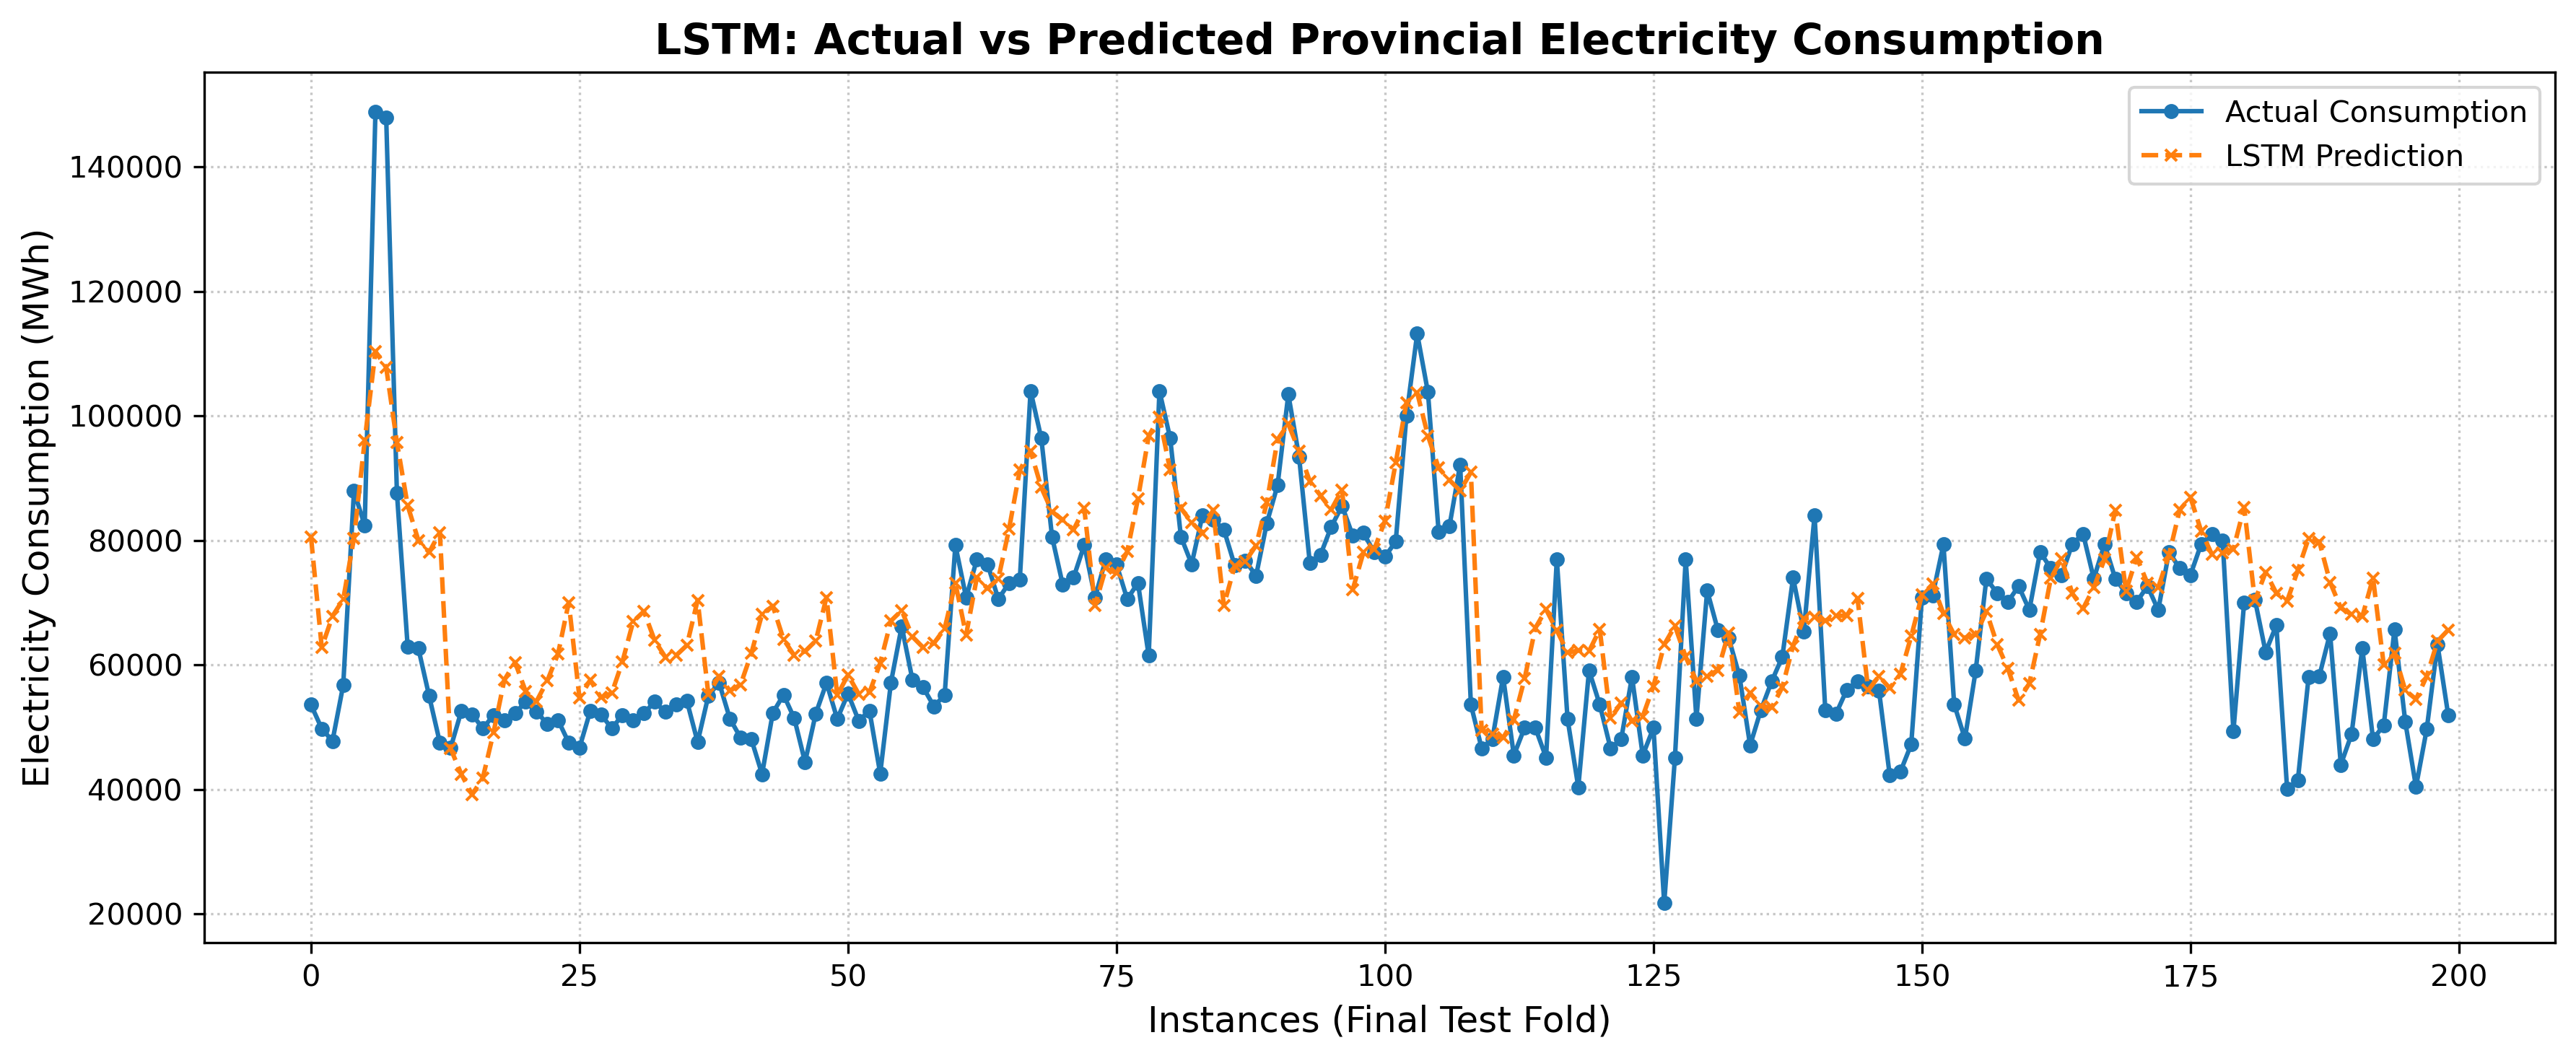

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ---------------------------------------------------------
# 1) DIEBOLD-MARIANO TEST FUNCTION
# ---------------------------------------------------------
def diebold_mariano(y_true, y_pred1, y_pred2):
    e1 = y_true - y_pred1
    e2 = y_true - y_pred2
    d = e1**2 - e2**2
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)
    dm_stat = mean_d / np.sqrt(var_d / len(d))
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))
    return dm_stat, p_value

# ---------------------------------------------------------
# 2) SEQUENCE GENERATOR
# ---------------------------------------------------------
def create_sequences(X, y, t):
    Xs, ys = [], []
    for i in range(t, len(X)):
        Xs.append(X[i-t:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

def main():
    # ---------------------------------------------------------
    # 3) DATA LOADING
    # ---------------------------------------------------------
    OUTPUT_PATH = os.path.join("..", "..", "processed_data", "final", "ML_En.xlsx")
    df = pd.read_excel(OUTPUT_PATH)
    
    df["Plate"] = df["Plate"].astype(str).str.lower()
    df = df.sort_values(["Plate", "Year", "Month"]).reset_index(drop=True)

    # ---------------------------------------------------------
    # 4) LAG FEATURES
    # ---------------------------------------------------------
    lag = 12
    for l in range(1, lag + 1):
        df[f"lag_{l}"] = df.groupby("Plate")["Consumption"].shift(l)

    df = df.dropna().reset_index(drop=True)

    # ---------------------------------------------------------
    # 5) FEATURE ENGINEERING
    # ---------------------------------------------------------
    features = [
        "Lighting", "Public", "Residential", "Industry", "Agriculture",
        "Population", "Latitude", "Longitude", "Daylight Duration",
        "Altitude", "Month", "Season", "Region"
    ] + [f"lag_{i}" for i in range(1, lag + 1)]

    X_df = df[features].copy()
    y_raw = df["Consumption"].values
    y_log = np.log1p(y_raw)  

    if X_df["Region"].dtype == 'object':
        X_df["Region"] = X_df["Region"].astype("category").cat.codes
    if X_df["Season"].dtype == 'object':
        X_df["Season"] = X_df["Season"].astype("category").cat.codes

    X = X_df.values

    # ---------------------------------------------------------
    # 6) TIME SERIES CROSS-VALIDATION
    # ---------------------------------------------------------
    tscv = TimeSeriesSplit(n_splits=5)
    fold_metrics = []
    timesteps = 12

    print("Starting LSTM Time-Series Cross-Validation...")

    final_y_true = None
    final_y_pred = None

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_log[train_idx], y_log[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        X_train_seq, y_train_seq = create_sequences(X_train, y_train, timesteps)
        X_test_seq, y_test_seq = create_sequences(X_test, y_test, timesteps)

        model = Sequential([
            LSTM(64, return_sequences=True, input_shape=(timesteps, X.shape[1])),
            Dropout(0.2),
            LSTM(32),
            Dense(32, activation="relu"),
            Dense(1)
        ])

        model.compile(optimizer="adam", loss="mse")
        model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, verbose=0)

        # Tahmin (Log ölçeğinde)
        y_pred_log = model.predict(X_test_seq, verbose=0).ravel()

        # Orijinal MWh birimine geri dönüş
        y_true_mwh = np.expm1(y_test_seq)
        y_pred_mwh = np.expm1(y_pred_log)
        
        # --- DÜZELTİLMİŞ METRİK HESAPLAMALARI (Orijinal Ölçekte) ---
        y_range = y_true_mwh.max() - y_true_mwh.min()
        y_range_safe = y_range if y_range != 0 else 1

        # Ham hatalar
        mse_val = mean_squared_error(y_true_mwh, y_pred_mwh)
        mae_val = mean_absolute_error(y_true_mwh, y_pred_mwh)

        # Normalizasyon (NMSE için paydanın karesi alındı)
        nmse = mse_val / (y_range_safe ** 2)
        nmae = mae_val / y_range_safe
        r2 = r2_score(y_true_mwh, y_pred_mwh)
        mape = np.mean(np.abs((y_true_mwh - y_pred_mwh) / (np.abs(y_true_mwh) + 1e-10))) * 100

        fold_metrics.append([r2, nmse, nmae, mape])
        print(f"Fold {fold} completed: R²={r2:.4f}, NMSE={nmse:.4f}, NMAE={nmae:.4f}")

        if fold == tscv.n_splits:
            final_y_true = y_true_mwh
            final_y_pred = y_pred_mwh

    # ---------------------------------------------------------
    # 7) AVERAGE CV RESULTS (Mean ± STD)
    # ---------------------------------------------------------
    fold_metrics = np.array(fold_metrics)
    print("\n" + "="*45)
    print("========= LSTM TIME-SERIES CV RESULTS =========")
    print("="*45)
    print(f"NMAE : {fold_metrics[:,2].mean():.4f} ± {fold_metrics[:,2].std():.4f}")
    print(f"NMSE : {fold_metrics[:,1].mean():.4f} ± {fold_metrics[:,1].std():.4f}")
    print(f"R²   : {fold_metrics[:,0].mean():.4f} ± {fold_metrics[:,0].std():.4f}")
    print(f"MAPE : {fold_metrics[:,3].mean():.2f}% ± {fold_metrics[:,3].std():.2f}%")
    print("="*45)

    # ---------------------------------------------------------
    # 8) DIEBOLD-MARIANO TEST (vs Naive)
    # ---------------------------------------------------------
    y_naive = pd.Series(final_y_true).shift(12).bfill().values
    dm_stat, p_value = diebold_mariano(final_y_true, final_y_pred, y_naive)
    print("\n" + "="*45)
    print("========== DIEBOLD-MARIANO TEST RESULT ==========")
    print("="*45)
    print(f"Comparison : LSTM Prediction vs. Naive Baseline (Lag 12)")
    print(f"DM Stat    : {dm_stat:.4f}")
    print(f"p-value    : {p_value:.4f}")
    print("="*45)

    # ---------------------------------------------------------
    # 9) PLOTTING (Orijinal MWh Birimiyle)
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 5), dpi=300)
    plot_limit = min(200, len(final_y_true))
    
    plt.plot(final_y_true[:plot_limit], label='Actual Consumption', color='#1f77b4', marker='o', markersize=4, linewidth=1.5)
    plt.plot(final_y_pred[:plot_limit], label='LSTM Prediction', color='#ff7f0e', marker='x', markersize=4, linestyle='--', linewidth=1.5)
    
    plt.title("LSTM: Actual vs Predicted Provincial Electricity Consumption", fontsize=14, fontweight='bold')
    plt.ylabel("Electricity Consumption (MWh)", fontsize=12)
    plt.xlabel("Instances (Final Test Fold)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.savefig("lstm_n_metrics_plot.png")
    plt.show()

if __name__ == "__main__":
    main()